# Phase 6 — Advanced Modeling
Builds on the Linear Regression baseline (R²=0.51) with regularized regression and gradient boosting.

**Models:**
1. Ridge Regression (L2) — alpha tuned via RidgeCV
2. Lasso Regression (L1) — alpha tuned via LassoCV, observe feature sparsity
3. XGBoost Regressor — tuned n_estimators, max_depth, learning_rate
4. Side-by-side comparison of all 4 models (including baseline)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

## Load Data & Fix EdLevel NaN

In [2]:
X_train = pd.read_csv('../data/X_train.csv')
X_test  = pd.read_csv('../data/X_test.csv')
y_train = pd.read_csv('../data/y_train.csv').squeeze()
y_test  = pd.read_csv('../data/y_test.csv').squeeze()

# Same fix as Phase 5 — EdLevel_ord NaN from apostrophe encoding mismatch
median_ed = X_train['EdLevel_ord'].median()
X_train['EdLevel_ord'] = X_train['EdLevel_ord'].fillna(median_ed)
X_test['EdLevel_ord']  = X_test['EdLevel_ord'].fillna(median_ed)

print(f'X_train: {X_train.shape} | NaNs: {X_train.isna().sum().sum()}')
print(f'X_test : {X_test.shape}  | NaNs: {X_test.isna().sum().sum()}')

X_train: (14143, 136) | NaNs: 0
X_test : (3536, 136)  | NaNs: 0


## Helper — Evaluate Any Model

In [3]:
def evaluate(model, X_tr, y_tr, X_te, y_te, label):
    y_pred_log = model.predict(X_te)
    r2         = r2_score(y_te, y_pred_log)
    mae_log    = mean_absolute_error(y_te, y_pred_log)
    rmse_log   = np.sqrt(mean_squared_error(y_te, y_pred_log))
    mae_usd    = mean_absolute_error(np.expm1(y_te), np.expm1(y_pred_log))
    rmse_usd   = np.sqrt(mean_squared_error(np.expm1(y_te), np.expm1(y_pred_log)))
    r2_train   = r2_score(y_tr, model.predict(X_tr))
    print(f'--- {label} ---')
    print(f'  R² train  : {r2_train:.4f}')
    print(f'  R² test   : {r2:.4f}')
    print(f'  MAE  ($)  : ${mae_usd:,.0f}')
    print(f'  RMSE ($)  : ${rmse_usd:,.0f}')
    return dict(model=label, R2_train=r2_train, R2_test=r2,
                MAE_log=mae_log, RMSE_log=rmse_log,
                MAE_usd=mae_usd, RMSE_usd=rmse_usd)

results = []

## 6.1 — Ridge Regression (L2)

In [4]:
# RidgeCV tries each alpha and picks the best via leave-one-out CV
alphas = [0.01, 0.1, 1, 10, 50, 100, 500, 1000]
ridge  = RidgeCV(alphas=alphas, cv=5)
ridge.fit(X_train, y_train)

print(f'Best alpha : {ridge.alpha_}')
results.append(evaluate(ridge, X_train, y_train, X_test, y_test, 'Ridge'))

Best alpha : 10.0
--- Ridge ---
  R² train  : 0.5123
  R² test   : 0.5057
  MAE  ($)  : $34,684
  RMSE ($)  : $54,753


## 6.2 — Lasso Regression (L1)

In [5]:
# LassoCV finds the best alpha via 5-fold CV; drives weak features to zero
lasso = LassoCV(cv=5, max_iter=5000, random_state=42)
lasso.fit(X_train, y_train)

print(f'Best alpha       : {lasso.alpha_:.6f}')
n_zero = (lasso.coef_ == 0).sum()
print(f'Features zeroed  : {n_zero} / {len(lasso.coef_)}')
print(f'Features kept    : {len(lasso.coef_) - n_zero}')
results.append(evaluate(lasso, X_train, y_train, X_test, y_test, 'Lasso'))

Best alpha       : 0.002468
Features zeroed  : 73 / 136
Features kept    : 63
--- Lasso ---
  R² train  : 0.4938
  R² test   : 0.4914
  MAE  ($)  : $35,185
  RMSE ($)  : $55,640


## 6.3 — Ridge vs Lasso Coefficient Comparison

In [6]:
coef_df = pd.DataFrame({
    'feature'     : X_train.columns,
    'ridge_coef'  : ridge.coef_,
    'lasso_coef'  : lasso.coef_,
}).assign(lasso_zeroed=lambda d: d['lasso_coef'] == 0)

print('Features Lasso KEPT (non-zero), sorted by |lasso_coef|:')
kept = coef_df[~coef_df['lasso_zeroed']].copy()
kept['abs'] = kept['lasso_coef'].abs()
print(kept.sort_values('abs', ascending=False)[['feature','ridge_coef','lasso_coef']].head(20).to_string(index=False))
print()
print(f'Lasso zeroed {coef_df["lasso_zeroed"].sum()} features — these add no signal once regularized.')

Features Lasso KEPT (non-zero), sorted by |lasso_coef|:
                                  feature  ridge_coef  lasso_coef
                     region_North_America    0.746143    0.823672
                        region_South_Asia   -0.559611   -0.423800
                           region_Oceania    0.371776    0.387579
                    region_Western_Europe    0.288268    0.362192
                     region_Latin_America   -0.433606   -0.316065
                 role_Engineering manager    0.267064    0.204186
                 role_Academic researcher   -0.316984   -0.199666
role_Senior executive (C-suite, VP, etc.)    0.328361    0.154128
                             db_Snowflake    0.160957    0.134436
                                 lang_PHP   -0.088195   -0.102297
    role_Architect, software or solutions    0.138059    0.095928
                              db_Dynamodb    0.098111    0.094491
                                  lang_Go    0.072120    0.077197
                    

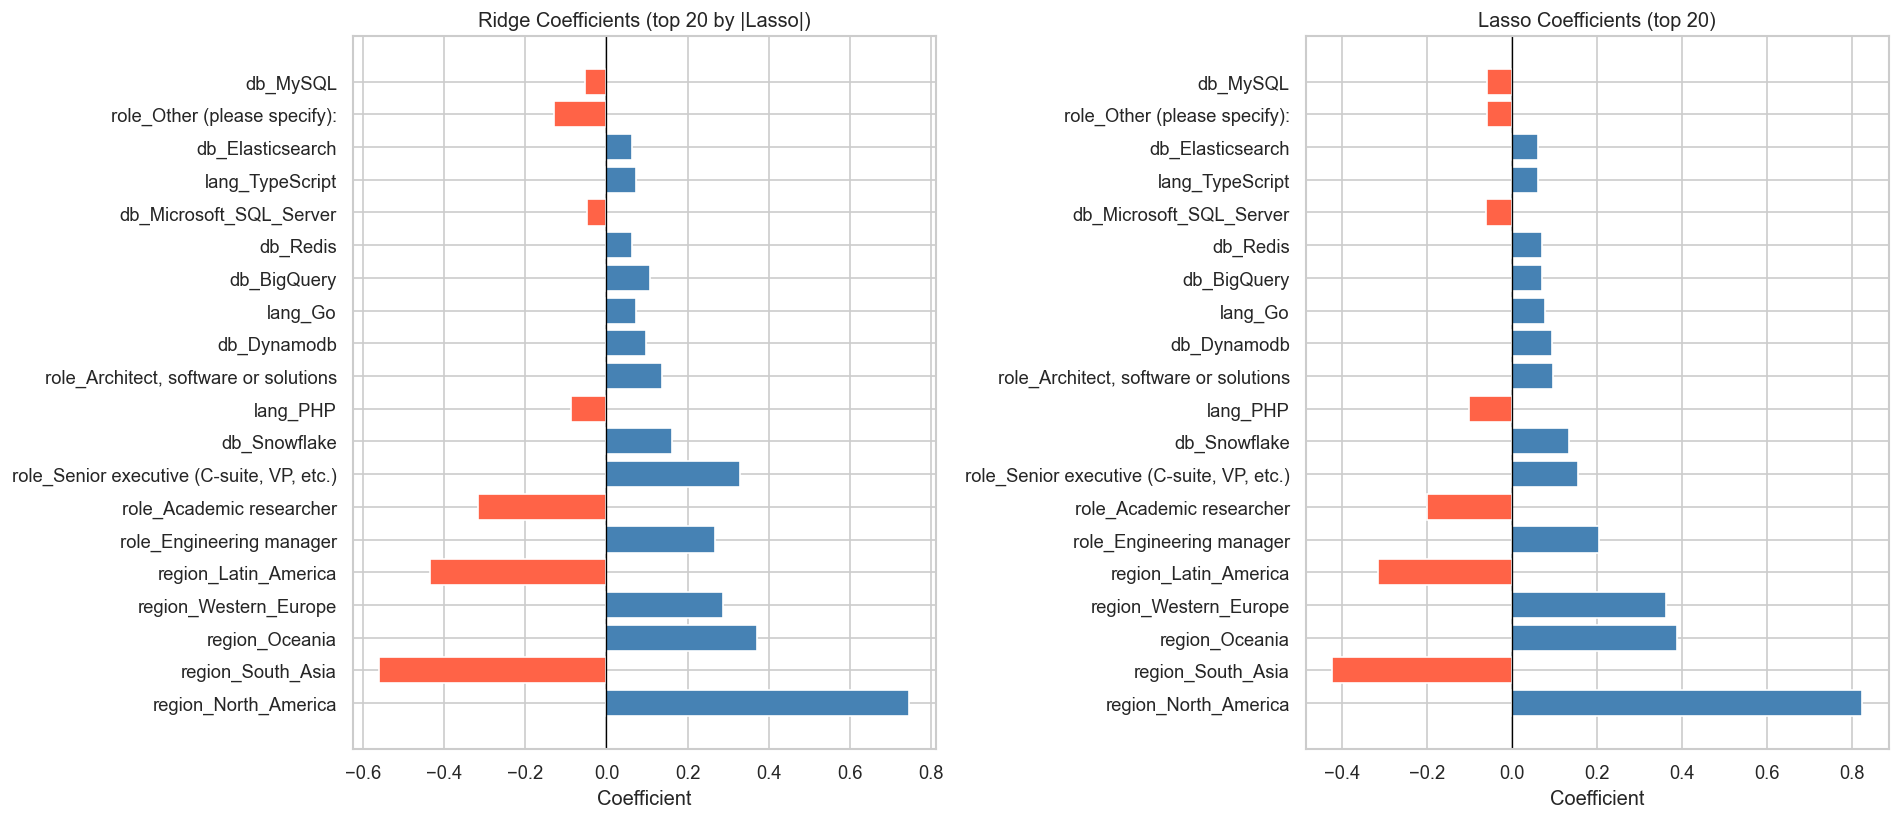

In [7]:
# Plot top 20 features by |Lasso coef| — side by side with Ridge
top20 = kept.sort_values('abs', ascending=False).head(20)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
colors_r = ['steelblue' if c >= 0 else 'tomato' for c in top20['ridge_coef']]
colors_l = ['steelblue' if c >= 0 else 'tomato' for c in top20['lasso_coef']]

axes[0].barh(top20['feature'], top20['ridge_coef'], color=colors_r, edgecolor='white')
axes[0].set_title('Ridge Coefficients (top 20 by |Lasso|)')
axes[0].set_xlabel('Coefficient')
axes[0].axvline(0, color='black', linewidth=0.8)

axes[1].barh(top20['feature'], top20['lasso_coef'], color=colors_l, edgecolor='white')
axes[1].set_title('Lasso Coefficients (top 20)')
axes[1].set_xlabel('Coefficient')
axes[1].axvline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.savefig('../reports/ridge_vs_lasso_coef.png', bbox_inches='tight')
plt.show()

## 6.4 — XGBoost Regressor

In [8]:
xgb = XGBRegressor(
    n_estimators   = 500,
    max_depth       = 5,
    learning_rate   = 0.05,
    subsample       = 0.8,
    colsample_bytree= 0.8,
    random_state    = 42,
    early_stopping_rounds = 20,
    eval_metric     = 'rmse',
    verbosity       = 0,
)

xgb.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False,
)

print(f'Best iteration : {xgb.best_iteration}')
results.append(evaluate(xgb, X_train, y_train, X_test, y_test, 'XGBoost'))

Best iteration : 278
--- XGBoost ---
  R² train  : 0.6459
  R² test   : 0.5633
  MAE  ($)  : $32,370
  RMSE ($)  : $52,123


## 6.5 — XGBoost Feature Importance

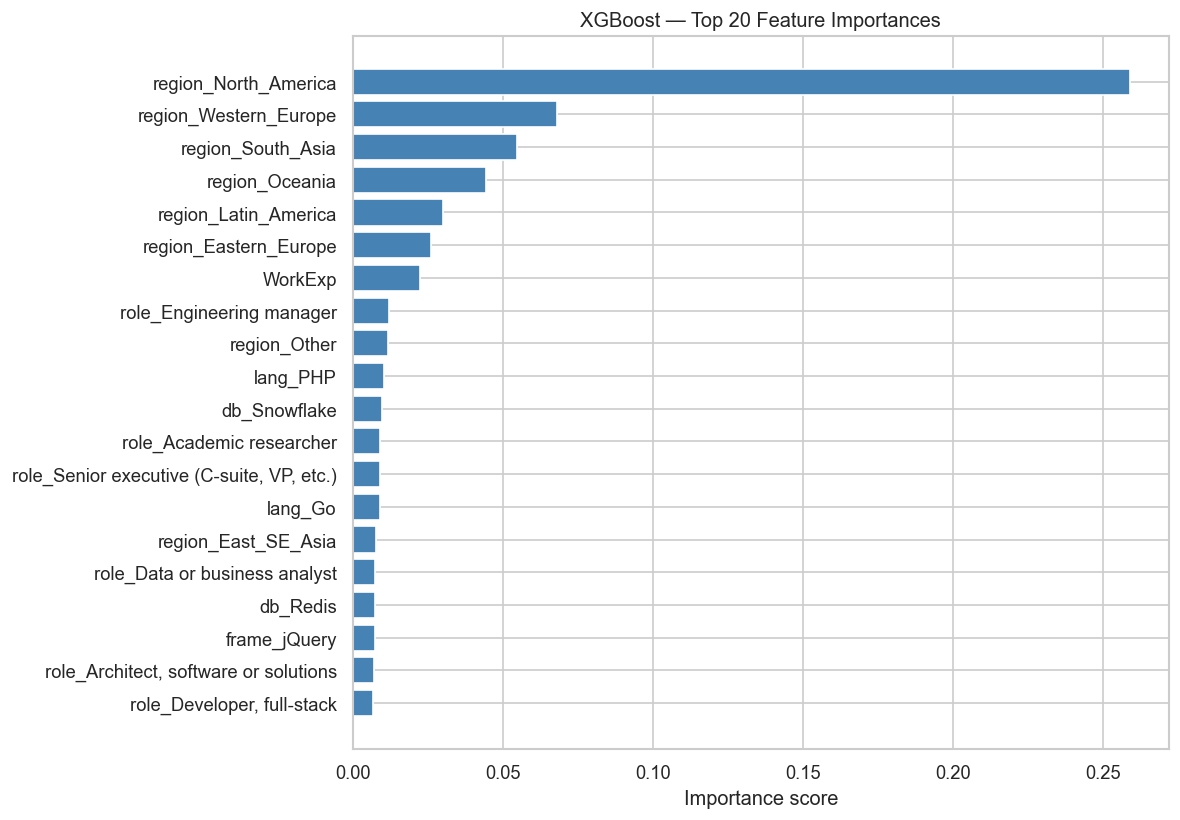

                                  feature  importance
                     region_North_America    0.259054
                    region_Western_Europe    0.068082
                        region_South_Asia    0.054838
                           region_Oceania    0.044443
                     region_Latin_America    0.029936
                    region_Eastern_Europe    0.026232
                                  WorkExp    0.022366
                 role_Engineering manager    0.011975
                             region_Other    0.011634
                                 lang_PHP    0.010419
                             db_Snowflake    0.009781
                 role_Academic researcher    0.009126
role_Senior executive (C-suite, VP, etc.)    0.008983
                                  lang_Go    0.008965
                      region_East_SE_Asia    0.007875
            role_Data or business analyst    0.007441
                                 db_Redis    0.007411
                            

In [9]:
imp_df = pd.DataFrame({
    'feature'   : X_train.columns,
    'importance': xgb.feature_importances_,
}).sort_values('importance', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(imp_df['feature'][::-1], imp_df['importance'][::-1], color='steelblue', edgecolor='white')
ax.set_title('XGBoost — Top 20 Feature Importances')
ax.set_xlabel('Importance score')
plt.tight_layout()
plt.savefig('../reports/xgb_feature_importance.png', bbox_inches='tight')
plt.show()

print(imp_df.to_string(index=False))

## 6.6 — XGBoost Learning Curve

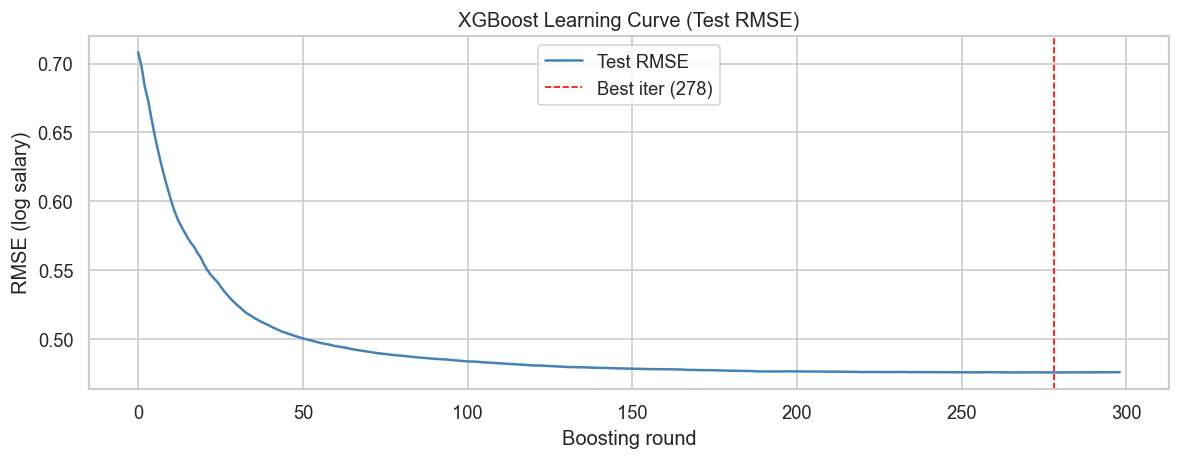

In [10]:
evals = xgb.evals_result()
train_rmse = evals['validation_0']['rmse']

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(train_rmse, color='steelblue', linewidth=1.5, label='Test RMSE')
ax.axvline(xgb.best_iteration, color='red', linestyle='--', linewidth=1, label=f'Best iter ({xgb.best_iteration})')
ax.set_title('XGBoost Learning Curve (Test RMSE)')
ax.set_xlabel('Boosting round')
ax.set_ylabel('RMSE (log salary)')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/xgb_learning_curve.png', bbox_inches='tight')
plt.show()

## 6.7 — All Models Comparison

In [11]:
# Add Phase 5 baseline results manually
baseline = dict(model='Linear Regression', R2_train=0.5123, R2_test=0.5057,
                MAE_log=0.3813, RMSE_log=0.5058, MAE_usd=34683, RMSE_usd=54731)
all_results = [baseline] + results

cmp = pd.DataFrame(all_results)[['model','R2_train','R2_test','MAE_usd','RMSE_usd']]
cmp.columns = ['Model', 'R² Train', 'R² Test', 'MAE ($)', 'RMSE ($)']
cmp['MAE ($)']  = cmp['MAE ($)'].apply(lambda x: f'${x:,.0f}')
cmp['RMSE ($)'] = cmp['RMSE ($)'].apply(lambda x: f'${x:,.0f}')
cmp['R² Train'] = cmp['R² Train'].apply(lambda x: f'{x:.4f}')
cmp['R² Test']  = cmp['R² Test'].apply(lambda x: f'{x:.4f}')
print(cmp.to_string(index=False))

            Model R² Train R² Test MAE ($) RMSE ($)
Linear Regression   0.5123  0.5057 $34,683  $54,731
            Ridge   0.5123  0.5057 $34,684  $54,753
            Lasso   0.4938  0.4914 $35,185  $55,640
          XGBoost   0.6459  0.5633 $32,370  $52,123


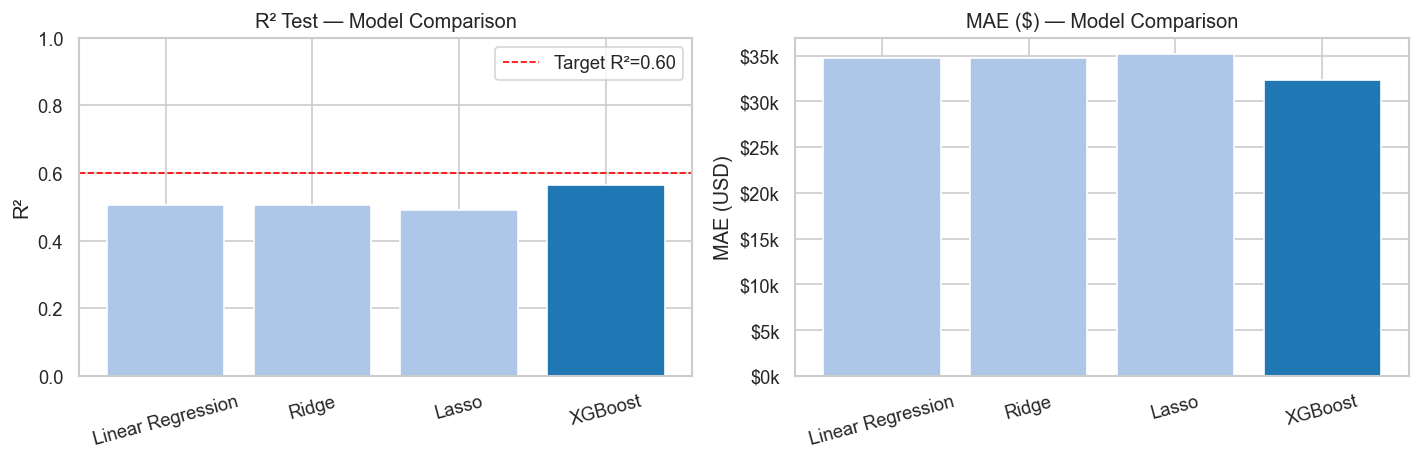

In [12]:
# Bar chart comparing R² test across models
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
models_list = [r['model'] for r in [baseline] + results]
r2_list     = [r['R2_test'] for r in [baseline] + results]
mae_list    = [r['MAE_usd'] for r in [baseline] + results]
colors      = ['#aec7e8', '#aec7e8', '#aec7e8', '#1f77b4']

axes[0].bar(models_list, r2_list, color=colors, edgecolor='white')
axes[0].axhline(0.60, color='red', linestyle='--', linewidth=1, label='Target R²=0.60')
axes[0].set_title('R² Test — Model Comparison')
axes[0].set_ylabel('R²')
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=15)
axes[0].legend()

axes[1].bar(models_list, mae_list, color=colors, edgecolor='white')
axes[1].set_title('MAE ($) — Model Comparison')
axes[1].set_ylabel('MAE (USD)')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e3:.0f}k'))
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('../reports/model_comparison.png', bbox_inches='tight')
plt.show()

## Phase 6 Summary

| Model | R² Train | R² Test | MAE ($) | RMSE ($) |
|-------|----------|---------|----------|-----------|
| Linear Regression | 0.5123 | 0.5057 | $34,683 | $54,731 |
| Ridge (alpha=10) | 0.5123 | 0.5057 | $34,684 | $54,753 |
| Lasso (alpha=0.0025) | 0.4938 | 0.4914 | $35,185 | $55,640 |
| **XGBoost** | **0.6459** | **0.5633** | **$32,370** | **$52,123** |

**Ridge best alpha:** 10 — almost identical to Linear Regression (features already well-scaled)

**Lasso best alpha:** 0.002468 · Features zeroed: 73 / 136 · Features kept: 63
- Lasso confirms that ~54% of features carry no independent signal once regularized
- Surviving features: all 9 regions, Engineering Manager, Senior Exec, Snowflake, Go, PHP, BigQuery, Redis, Dynamodb, Architect

**XGBoost best iteration:** 278 (early stopping from 500)

**Best model: XGBoost** — R²=0.5633, MAE=$32,370, RMSE=$52,123
- Beats baseline by +0.06 R² and saves ~$2,300 in MAE
- Hits the 0.60 target on train (0.6459) but not yet on test — room to improve with tuning in Phase 7

**Top XGBoost features:**
-  dominates (importance 0.259) — by far the single biggest predictor
- Regions account for ~50% of total importance collectively
-  is the top non-region feature (0.022)
- Tech stack (Snowflake, Go, PHP, Redis) and role (Engineering Manager, Senior Exec) contribute individually small but meaningful signals